# Analisis Numerik: Regresi & Pencarian Akar
## Studi Kasus: Titik Impas (*Breakeven Point*) 5 Gerai Donat

**Topik:** Regresi (least-squares) & Pencarian Akar (*root finding*)

**Sumber data:** [`sintesis_data_donat_harian.csv`](https://github.com/jendralhxr/metnummatdis/blob/main/sintesis_data_donat_harian.csv)


### Alur Analisis
1. **Eksplorasi & Plot** : hubungan *Jumlah Penjualan* (volume, unit) vs *Revenue* (pendapatan kotor, Rp) untuk kelima gerai.
2. **Regresi** : mencari model matematis (linear/polinomial) yang menjelaskan **Revenue** dan **Total Biaya** sebagai fungsi dari volume penjualan.
3. **Pencarian Akar** : menggunakan metode **Bisection** dan **Newton-Raphson** untuk mencari volume penjualan yang membuat *Laba* = Revenue - Biaya = 0 (titik impas / BEP), berdasarkan model regresi pada langkah 2.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
import os, urllib.request

LOCAL_PATH = "sintesis_data_donat_harian.csv"
RAW_URL = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"

if not os.path.exists(LOCAL_PATH):
    urllib.request.urlretrieve(RAW_URL, LOCAL_PATH)

df = pd.read_csv(LOCAL_PATH, parse_dates=['Tanggal'])
df['Total Biaya (Rp)'] = df['Biaya Variabel (Rp)'] + df['Fixed Cost Harian (Rp)']

GERAI_LIST = sorted(df['Gerai'].unique())
COLORS = {'Gerai A': '#e63946', 'Gerai B': '#457b9d', 'Gerai C': '#2a9d8f',
          'Gerai D': '#f4a261', 'Gerai E': '#6d597a'}

print(f"Jumlah baris  : {len(df)}")
print(f"Gerai         : {GERAI_LIST}")
print(f"Rentang tanggal: {df['Tanggal'].min().date()} s.d. {df['Tanggal'].max().date()}")
df.head(10)


Jumlah baris  : 450
Gerai         : ['Gerai A', 'Gerai B', 'Gerai C', 'Gerai D', 'Gerai E']
Rentang tanggal: 2026-01-01 s.d. 2026-03-31


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp),Total Biaya (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833,2422833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833,2371833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667,2618333
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167,2694833
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333,2482333
5,2026-01-06,Gerai A,25000,90,2250000,765000,1683333,-198333,2448333
6,2026-01-07,Gerai A,25000,85,2125000,722500,1683333,-280833,2405833
7,2026-01-08,Gerai A,25000,87,2175000,739500,1683333,-247833,2422833
8,2026-01-09,Gerai A,25000,84,2100000,714000,1683333,-297333,2397333
9,2026-01-10,Gerai A,25000,119,2975000,1011500,1683333,280167,2694833


In [3]:
summary = df.groupby('Gerai').agg(
    Harga_Jual = ('Harga Jual (Rp)', 'first'),
    Vol_Min    = ('Jumlah Terjual (Unit)', 'min'),
    Vol_Max    = ('Jumlah Terjual (Unit)', 'max'),
    Vol_Mean   = ('Jumlah Terjual (Unit)', 'mean'),
    Fixed_Cost = ('Fixed Cost Harian (Rp)', 'first'),
    Balance_Mean = ('Balance (Rp)', 'mean'),
    Hari_Rugi  = ('Balance (Rp)', lambda x: (x < 0).sum()),
)
summary


,Harga_Jual,Vol_Min,Vol_Max,Vol_Mean,Fixed_Cost,Balance_Mean,Hari_Rugi
Gerai,,,,,,,
Gerai A,25000,81,131,99.10,1683333,"-48,183.00",59
Gerai B,8000,435,710,527.50,733333,"1,292,267.00",0
Gerai C,11000,220,522,328.93,1733333,"292,896.33",28
Gerai D,20000,103,223,149.83,2666666,"-748,799.33",86
Gerai E,15000,153,332,226.64,800000,"1,171,806.67",0


## 1. Plot: Jumlah Penjualan vs Revenue (30%)

Setiap titik merepresentasikan satu hari operasional. Karena Pendapatan Kotor = Harga Jual × Jumlah Terjual,
untuk masing-masing gerai (harga jualnya tetap) pola yang muncul secara alami adalah garis lurus melalui titik asal
dengan kemiringan sebesar harga jual per unit.

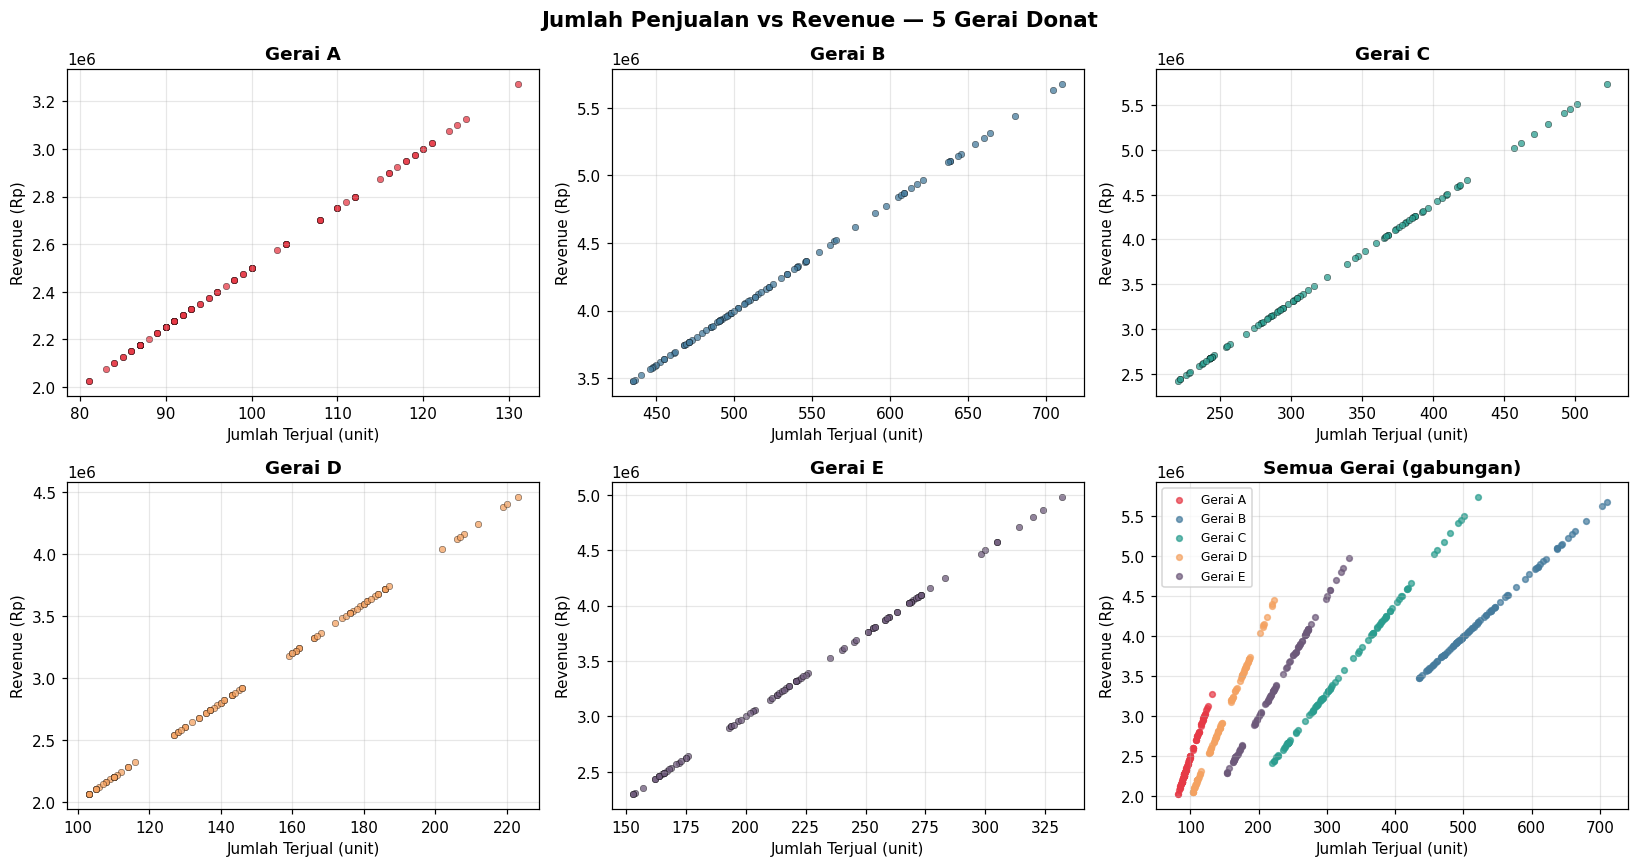

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, g in enumerate(GERAI_LIST):
    sub = df[df['Gerai'] == g]
    axes[i].scatter(sub['Jumlah Terjual (Unit)'], sub['Pendapatan Kotor (Rp)'],
                     s=18, color=COLORS[g], alpha=0.75, edgecolor='k', linewidth=0.3)
    axes[i].set_title(g, fontweight='bold')
    axes[i].set_xlabel('Jumlah Terjual (unit)')
    axes[i].set_ylabel('Revenue (Rp)')

# panel gabungan di slot ke-6
ax = axes[5]
for g in GERAI_LIST:
    sub = df[df['Gerai'] == g]
    ax.scatter(sub['Jumlah Terjual (Unit)'], sub['Pendapatan Kotor (Rp)'],
               s=14, color=COLORS[g], alpha=0.7, label=g)
ax.set_title('Semua Gerai (gabungan)', fontweight='bold')
ax.set_xlabel('Jumlah Terjual (unit)')
ax.set_ylabel('Revenue (Rp)')
ax.legend(fontsize=8)

plt.suptitle('Jumlah Penjualan vs Revenue — 5 Gerai Donat', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_volume_vs_revenue.png', bbox_inches='tight')
plt.show()


Sumbu-x (volume) berbeda skala jauh antar gerai (Gerai B menjual ratusan unit/hari,
Gerai A puluhan saja) mencerminkan strategi *mass market* vs *niche premium*. Kemiringan garis (Revenue/Volume)
sama dengan harga jual per unit masing-masing gerai (Rp 8.000 s.d. Rp 25.000).

## 2. Regresi: Model Revenue & Biaya terhadap Volume Penjualan (30%)

### 2.1 Fungsi regresi least-square

Regresi polinomial derajat‑$n$ dicari dengan menyusun matriks Vandermonde $X$ dan menyelesaikan
sistem normal $\left(X^{T}X\right)\hat{\beta}=X^{T}y$ (diselesaikan numerik dengan SVD via numpy.linalg.lstsq
agar stabil), lalu dihitung koefisien determinasi $R^2$ untuk menilai kecocokan model.

In [5]:
def regresi_polinomial(x, y, derajat=1):
    """Least-squares polynomial regression.
    Mengembalikan koefisien (derajat tertinggi -> konstanta) dan R^2.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    # matriks Vandermonde: kolom [x^n, x^(n-1), ..., x^0]
    X = np.vander(x, N=derajat + 1)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
    return beta, r2

def evaluasi_polinomial(beta, x):
    return np.polyval(beta, x)


### 2.2 Uji beberapa derajat polinomial (Revenue vs Volume)

Untuk memastikan bentuk model yang dipakai (linear/polinomial/lainnya) benar-benar yang terbaik, dicoba
derajat 1 sampai 3 dan dibandingkan $R^2$-nya untuk salah satu gerai (representatif).

In [6]:
contoh = 'Gerai C'
sub = df[df['Gerai'] == contoh]
v = sub['Jumlah Terjual (Unit)'].values
rev = sub['Pendapatan Kotor (Rp)'].values

print(f"Perbandingan derajat polinomial - Revenue vs Volume ({contoh})")
print(f"{'Derajat':<10}{'R^2':<12}{'Koefisien (derajat tinggi -> rendah)'}")
for d in [1, 2, 3]:
    beta, r2 = regresi_polinomial(v, rev, derajat=d)
    print(f"{d:<10}{r2:<12.6f}{np.round(beta, 4)}")


Perbandingan derajat polinomial - Revenue vs Volume (Gerai C)
Derajat   R^2         Koefisien (derajat tinggi -> rendah)
1         1.000000    [11000.     0.]
2         1.000000    [    0. 11000.    -0.]
3         1.000000    [   -0.     0. 11000.    -0.]


Derajat‑1 (linear) sudah menghasilkan $R^2 \approx 1$  penambahan derajat lebih tinggi tidak
memberi perbaikan berarti (koefisien orde tinggi ≈ 0). Ini konsisten dengan hubungan struktural
Revenue = Harga Jual × Volume, yang memang linear. Model linear dipilih untuk seluruh analisis
selanjutnya (prinsip parsimoni, model paling sederhana yang sudah menjelaskan data dengan baik).

Hal yang sama berlaku untuk Total Biaya (Biaya Variabel + Fixed Cost) terhadap volume, karena struktur
biaya donat bersifat *cost-volume-profit* klasik: Biaya = Fixed Cost + Biaya Variabel/unit × Volume.

In [7]:
hasil_regresi = {}

for g in GERAI_LIST:
    sub = df[df['Gerai'] == g]
    v    = sub['Jumlah Terjual (Unit)'].values
    rev  = sub['Pendapatan Kotor (Rp)'].values
    cost = sub['Total Biaya (Rp)'].values

    beta_rev,  r2_rev  = regresi_polinomial(v, rev,  derajat=1)
    beta_cost, r2_cost = regresi_polinomial(v, cost, derajat=1)

    hasil_regresi[g] = {
        'slope_revenue': beta_rev[0],   'intercept_revenue': beta_rev[1], 'r2_revenue': r2_rev,
        'slope_cost':    beta_cost[0],  'intercept_cost':    beta_cost[1], 'r2_cost':    r2_cost,
    }

hasil_df = pd.DataFrame(hasil_regresi).T
hasil_df.index.name = 'Gerai'
hasil_df


,slope_revenue,intercept_revenue,r2_revenue,slope_cost,intercept_cost,r2_cost
Gerai,,,,,,
Gerai A,"25,000.00",0.00,1.00,"8,500.00","1,683,333.00",1.00
Gerai B,"8,000.00",-0.00,1.00,"4,160.00","733,333.00",1.00
Gerai C,"11,000.00",0.00,1.00,"4,840.00","1,733,333.00",1.00
Gerai D,"20,000.00",-0.00,1.00,"7,200.00","2,666,666.00",1.00
Gerai E,"15,000.00",-0.00,1.00,"6,300.00","800,000.00",1.00


### 2.3 Visualisasi garis regresi Revenue & Biaya terhadap Volume

Titik potong (jika ada, pada rentang volume positif) antara garis Revenue dan garis Biaya Total adalah
perkiraan visual dari titik impas (BEP) akan dihitung presisinya pada Bagian 3 dengan metode numerik.

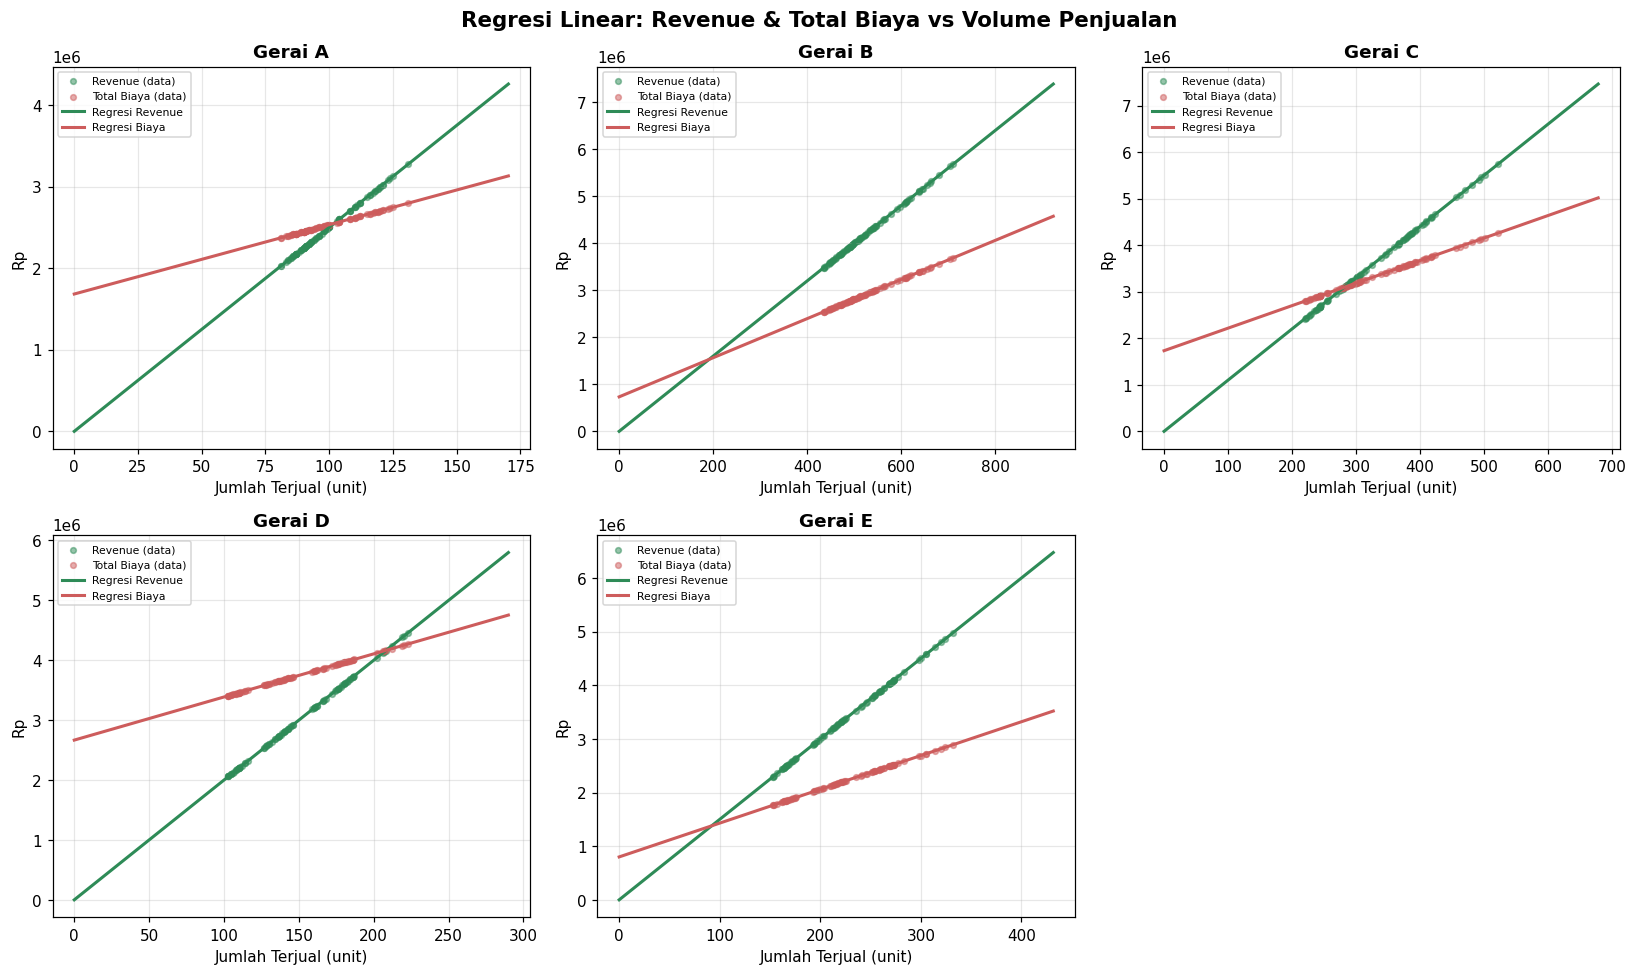

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, g in enumerate(GERAI_LIST):
    sub = df[df['Gerai'] == g]
    v    = sub['Jumlah Terjual (Unit)'].values
    rev  = sub['Pendapatan Kotor (Rp)'].values
    cost = sub['Total Biaya (Rp)'].values

    v_line = np.linspace(0, v.max() * 1.3, 200)
    beta_rev  = [hasil_regresi[g]['slope_revenue'],  hasil_regresi[g]['intercept_revenue']]
    beta_cost = [hasil_regresi[g]['slope_cost'],     hasil_regresi[g]['intercept_cost']]

    ax = axes[i]
    ax.scatter(v, rev,  s=14, color='seagreen', alpha=0.5, label='Revenue (data)')
    ax.scatter(v, cost, s=14, color='indianred', alpha=0.5, label='Total Biaya (data)')
    ax.plot(v_line, evaluasi_polinomial(beta_rev,  v_line), color='seagreen', lw=2, label='Regresi Revenue')
    ax.plot(v_line, evaluasi_polinomial(beta_cost, v_line), color='indianred', lw=2, label='Regresi Biaya')
    ax.set_title(g, fontweight='bold')
    ax.set_xlabel('Jumlah Terjual (unit)')
    ax.set_ylabel('Rp')
    ax.legend(fontsize=7)

axes[5].axis('off')
plt.suptitle('Regresi Linear: Revenue & Total Biaya vs Volume Penjualan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_regresi_revenue_biaya.png', bbox_inches='tight')
plt.show()


## 3. Pencarian Akar: Titik Impas / Breakeven Point (40%)

### 3.1 Fungsi Laba

Dari hasil regresi Bagian 2, model Laba sebagai fungsi volume $v$ untuk setiap gerai adalah:

$$f(v) = \text{Revenue}(v) - \text{Biaya}(v) = (m_{rev}-m_{cost})\,v + (c_{rev}-c_{cost})$$

Titik impas (BEP) adalah nilai $v$ sedemikian sehingga $f(v)=0$. Nilai ini dicari dengan dua metode
numerik pencarian akar: **Metode Bisection** dan **Metode Newton-Raphson**, lalu hasilnya dibandingkan
dengan solusi analitik $v^{*}=-c/m$ sebagai validasi.

In [9]:
def buat_fungsi_laba(g):
    """Mengembalikan fungsi f(v) dan turunannya f'(v) untuk gerai g, berdasarkan regresi linear."""
    m = hasil_regresi[g]['slope_revenue']  - hasil_regresi[g]['slope_cost']
    c = hasil_regresi[g]['intercept_revenue'] - hasil_regresi[g]['intercept_cost']
    f  = lambda v: m * v + c
    df_ = lambda v: m + 0 * np.asarray(v)   # turunan konstan = m
    return f, df_, m, c


In [10]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    """Metode Bisection untuk mencari akar f(x)=0 pada interval [a,b]."""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) dan f(b) harus berbeda tanda (tidak ada jaminan akar pada interval ini).")

    riwayat = []
    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        error = abs(b - a) / 2
        riwayat.append((i, a, b, c, fc, error))
        if abs(fc) < tol or error < tol:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, pd.DataFrame(riwayat, columns=['iterasi', 'a', 'b', 'c (taksiran akar)', 'f(c)', 'error'])


def newton_raphson(f, fprime, x0, tol=1e-6, max_iter=100):
    """Metode Newton-Raphson untuk mencari akar f(x)=0, mulai dari tebakan awal x0."""
    riwayat = []
    x = x0
    for i in range(1, max_iter + 1):
        fx  = f(x)
        fpx = fprime(x)
        if fpx == 0:
            raise ZeroDivisionError("Turunan nol - Newton-Raphson gagal konvergen.")
        x_baru = x - fx / fpx
        error = abs(x_baru - x)
        riwayat.append((i, x, fx, fpx, x_baru, error))
        x = x_baru
        if error < tol:
            break
    return x, pd.DataFrame(riwayat, columns=['iterasi', 'x_n', 'f(x_n)', "f'(x_n)", 'x_(n+1)', 'error'])


### 3.2 Ilustrasi iterasi

Gerai D dipilih sebagai ilustrasi karena memiliki fixed cost (sewa) tertinggi, sehingga BEP-nya
paling menarik untuk diperiksa terhadap volume penjualan aktualnya.

In [11]:
g_contoh = 'Gerai D'
f, fprime, m, c = buat_fungsi_laba(g_contoh)
v_data = df[df['Gerai'] == g_contoh]['Jumlah Terjual (Unit)']

# interval awal untuk bisection: 0 s.d. 2x volume maksimum harian yang tercatat
a0, b0 = 0.0, float(v_data.max() * 2)

akar_bis, riwayat_bis = bisection(f, a0, b0, tol=1e-4)
print(f"[Bisection]      BEP ≈ {akar_bis:.4f} unit  |  iterasi = {len(riwayat_bis)}")
display(riwayat_bis.head(10))


[Bisection]      BEP ≈ 208.3333 unit  |  iterasi = 23


,iterasi,a,b,c (taksiran akar),f(c),error
0,1,0.00,446.00,223.00,"187,734.00",223.00
1,2,0.00,223.00,111.50,"-1,239,466.00",111.50
2,3,111.50,223.00,167.25,"-525,866.00",55.75
3,4,167.25,223.00,195.12,"-169,066.00",27.88
4,5,195.12,223.00,209.06,"9,334.00",13.94
5,6,195.12,209.06,202.09,"-79,866.00",6.97
6,7,202.09,209.06,205.58,"-35,266.00",3.48
7,8,205.58,209.06,207.32,"-12,966.00",1.74
8,9,207.32,209.06,208.19,"-1,816.00",0.87
9,10,208.19,209.06,208.63,"3,759.00",0.44


In [12]:
x0 = float(v_data.mean())  # tebakan awal Newton-Raphson: rata-rata volume aktual
akar_nr, riwayat_nr = newton_raphson(f, fprime, x0, tol=1e-6)
print(f"[Newton-Raphson] BEP ≈ {akar_nr:.4f} unit  |  iterasi = {len(riwayat_nr)}  |  tebakan awal x0 = {x0:.2f}")
riwayat_nr


[Newton-Raphson] BEP ≈ 208.3333 unit  |  iterasi = 2  |  tebakan awal x0 = 149.83


,iterasi,x_n,f(x_n),f'(x_n),x_(n+1),error
0,1,149.83,"-748,799.33","12,800.00",208.33,58.50
1,2,208.33,0.00,"12,800.00",208.33,0.00


Newton-Raphson konvergen dalam satu langkah karena $f(v)$ adalah fungsi linear
(turunannya konstan $=m$, sehingga garis singgung = garis fungsi itu sendiri). Ini adalah hasil yang
diharapkan secara teoritis dan sekaligus menjadi validasi bahwa implementasi metode sudah benar.

### 3.3 BEP untuk kelima gerai (Bisection & Newton-Raphson)

In [13]:
bep_hasil = []

for g in GERAI_LIST:
    f, fprime, m, c = buat_fungsi_laba(g)
    v_data = df[df['Gerai'] == g]['Jumlah Terjual (Unit)']

    a0, b0 = 0.0, float(v_data.max() * 2)
    akar_bis, hist_bis = bisection(f, a0, b0, tol=1e-4)

    x0 = float(v_data.mean())
    akar_nr, hist_nr = newton_raphson(f, fprime, x0, tol=1e-6)

    akar_analitik = -c / m

    v_mean = v_data.mean()
    status = 'DI ATAS BEP (rata-rata untung)' if v_mean > akar_bis else 'DI BAWAH BEP (rata-rata rugi)'

    bep_hasil.append({
        'Gerai': g,
        'BEP - Bisection (unit)': akar_bis,
        'BEP - Newton-Raphson (unit)': akar_nr,
        'BEP - Analitik (unit)': akar_analitik,
        'Iterasi Bisection': len(hist_bis),
        'Iterasi Newton-Raphson': len(hist_nr),
        'Volume Rata-rata Aktual (unit)': v_mean,
        'Status': status,
    })

bep_df = pd.DataFrame(bep_hasil).set_index('Gerai')
bep_df


,BEP - Bisection (unit),BEP - Newton-Raphson (unit),BEP - Analitik (unit),Iterasi Bisection,Iterasi Newton-Raphson,Volume Rata-rata Aktual (unit),Status
Gerai,,,,,,,
Gerai A,102.02,102.02,102.02,22,2,99.10,DI BAWAH BEP (rata-rata rugi)
Gerai B,190.97,190.97,190.97,24,2,527.50,DI ATAS BEP (rata-rata untung)
Gerai C,281.39,281.39,281.39,24,2,328.93,DI ATAS BEP (rata-rata untung)
Gerai D,208.33,208.33,208.33,23,2,149.83,DI BAWAH BEP (rata-rata rugi)
Gerai E,91.95,91.95,91.95,23,2,226.64,DI ATAS BEP (rata-rata untung)


### 3.4 Visualisasi Titik Impas

Grafik berikut menandai posisi BEP terhadap sebaran volume penjualan harian aktual
untuk masing-masing gerai.

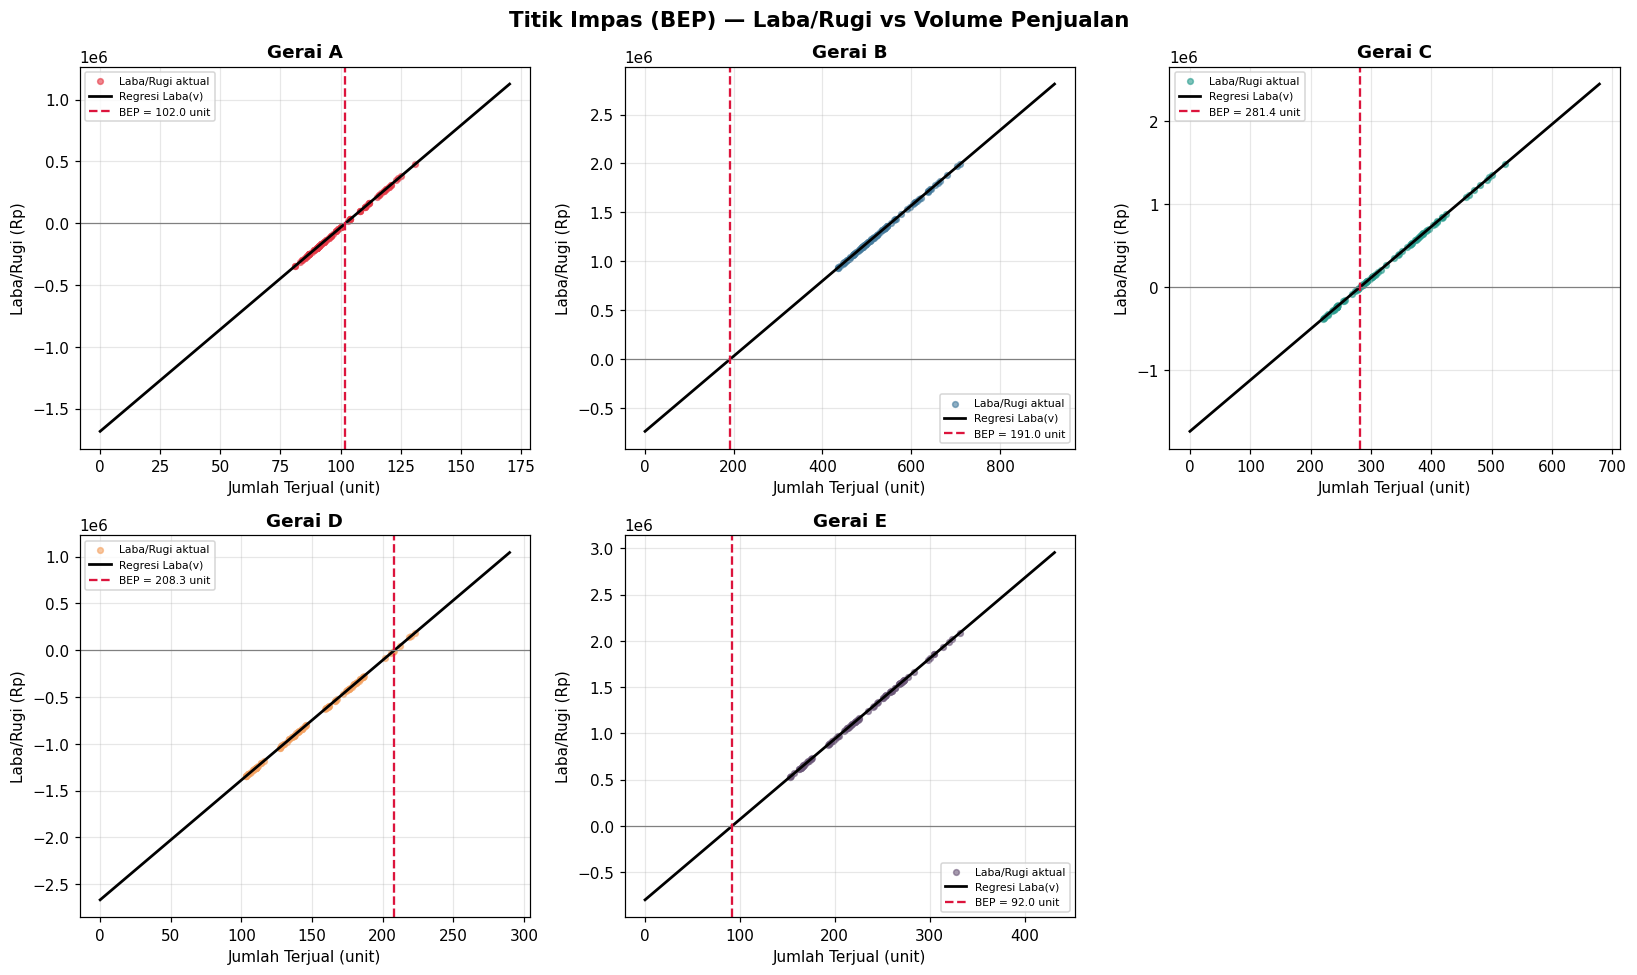

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, g in enumerate(GERAI_LIST):
    sub = df[df['Gerai'] == g]
    v    = sub['Jumlah Terjual (Unit)'].values
    laba = sub['Balance (Rp)'].values
    bep  = bep_df.loc[g, 'BEP - Bisection (unit)']

    v_line = np.linspace(0, v.max() * 1.3, 200)
    f, _, _, _ = buat_fungsi_laba(g)
    laba_line = f(v_line)

    ax = axes[i]
    ax.scatter(v, laba, s=14, color=COLORS[g], alpha=0.6, label='Laba/Rugi aktual')
    ax.plot(v_line, laba_line, color='black', lw=1.8, label='Regresi Laba(v)')
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(bep, color='crimson', ls='--', lw=1.5, label=f'BEP = {bep:.1f} unit')
    ax.set_title(g, fontweight='bold')
    ax.set_xlabel('Jumlah Terjual (unit)')
    ax.set_ylabel('Laba/Rugi (Rp)')
    ax.legend(fontsize=7)

axes[5].axis('off')
plt.suptitle('Titik Impas (BEP) — Laba/Rugi vs Volume Penjualan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_bep.png', bbox_inches='tight')
plt.show()


## 4. Kesimpulan

1. Revenue = Harga × Volume dan Biaya = Fixed Cost Biaya Variabel/unit × Volume bersifat
  linear secara struktural pada data ini (harga & biaya per unit konstan), model regresi terbaik untuk
  seluruh gerai adalah linear ($R^2 \approx 1$ pada semua kasus) dikonfirmasi dengan membandingkan
  terhadap regresi polinomial derajat lebih tinggi yang tidak memberi perbaikan.
2. Karena fungsi laba $f(v)$ linear, metode Bisection dan Newton-Raphson menghasilkan akar (BEP)
  yang identik dan sama dengan solusi analitik $v^{*}=-c/m$ ini menjadi validasi silang bagi kebenaran
  implementasi kedua algoritma.
3. Insight bisnis: Gerai A dan D adalah yang paling berisiko (beroperasi rata-rata di sekitar/di
  bawah BEP), konsisten dengan strategi mereka masing-masing (pasar niche terbatas untuk A, dan fixed
  cost sewa mall yang tinggi untuk D). Gerai B dan E memiliki *margin of safety* volume terbesar.
